In [1]:
from dlfs.layers import EmbeddingLayer, PositionalEncoding, DenseLayer
from dlfs.modules import Transformer

from dlfs.activation import Softmax, ReLU
from dlfs.loss import CCE_Loss
from dlfs.optimizers import Optimizer_Adam

from dlfs.base import Module, Activation, Loss, Optimizer
from dlfs.helpers import get_random_batch

import numpy as np

# Transformer encoder-decoder model

In [2]:
class TransformerModel(Module):

    def __init__(self, vocab_size: int, seq_len: int, 
                       n_embed: int = 512, n_head: int = 4, n_enc_layers: int = 2, n_dec_layers: int = 2, dim_ff: int = 2048, 
                       dropout: float = 0.1, activation: Activation = ReLU, layer_norm_eps: float = 1e-5, 
                       loss_function: Loss = None, optimizer: Optimizer = None) -> None:
        """
        Original Transformer model from the paper 'Attention is All You Need' by Vaswani et al. (2017).
        This model includes input and output embeddings, sinusoidal positional encoding, Transformer encoder and decoder layers, 
        and a final linear layer for prediction.

        Parameters
        ----------
        vocab_size : int
            The size of the vocabulary, the total number of unique tokens (words/characters) in the dataset.

        seq_len : int
            The maximum sequence length of the input/output sequences.

        n_embed : int, default=512
            The dimensionality of the embedding vectors for both input and output.

        n_head : int, default=4
            The number of attention heads in each attention layer.

        n_enc_layers : int, default=2
            The number of layers in the Transformer encoder.

        n_dec_layers : int, default=2
            The number of layers in the Transformer decoder.

        dim_ff : int, default=2048
            The dimensionality of the feedforward layers in the encoder and decoder.

        dropout : float, default=0.1
            The dropout rate applied to layers during training to help prevent overfitting.

        activation : Activation, default=ReLU
            The activation function used in the feedforward layers.

        layer_norm_eps : float, default=1e-5
            A small value added to the denominator for numerical stability when performing layer normalization.

        loss_function : Loss, default=None
            The loss function used during training.

        optimizer : Optimizer, default=None
            The optimizer used for training.

        Returns
        -------
        None
        """
        
        self.loss_function = loss_function
        self.optimizer = optimizer

        self.embed_enc = EmbeddingLayer(vocab_size, n_embed)
        self.pos_enc_enc = PositionalEncoding(seq_len, n_embed)

        self.embed_dec = EmbeddingLayer(vocab_size, n_embed)
        self.pos_enc_dec = PositionalEncoding(seq_len, n_embed)

        self.transformer = Transformer(d_model=n_embed, n_head=n_head, n_enc_layers=n_enc_layers, n_dec_layers=n_dec_layers,
                                       dim_ff=dim_ff, dropout=dropout, activation=activation, layer_norm_eps=layer_norm_eps)

        self.linear = DenseLayer(n_embed, vocab_size)
        self.softm = Softmax()

    def forward(self, inputs_enc: np.ndarray, inputs_dec: np.ndarray, training: bool = False) -> None:
        """
        Forward pass for the Transformer model. Creates output attribute (logits) of shape (batch_size, seq_len, vocab_size).

        Parameters
        ----------
        inputs_enc : np.ndarray
            The input sequence for the encoder of shape `(batch_size, seq_len)`.

        inputs_dec : np.ndarray
            The input sequence for the decoder of shape `(batch_size, seq_len)`.

        training : bool, default=False
            A flag indicating whether the model is in training mode (`True`) or inference mode (`False`).
            This controls dropout, which is only applied during training.

        Returns
        -------
        None

        Notes
        -----
        - `inputs_enc` and `inputs_dec` are expected to be token indices for the respective encoder and decoder sequences.
        - The output is typically passed through a softmax function externally for final predictions (e.g., during inference).
        """

        # Embed encoder input, outputs (batch_size, seq_len, n_embed)
        self.embed_enc.forward(inputs_enc, training)
        # Add positional encoding to embeddings, outputs (batch_size, seq_len, n_embed)
        self.pos_enc_enc.forward(self.embed_enc.output, training)

        # Embed decoder input, outputs (batch_size, seq_len, n_embed)
        self.embed_dec.forward(inputs_dec, training)
        # Add positional encoding to embeddings, outputs (batch_size, seq_len, n_embed)
        self.pos_enc_dec.forward(self.embed_dec.output, training)

        # Pass encoder and decoder inputs through the Transformer, outputs (batch_size, seq_len, n_embed)
        self.transformer.forward(self.pos_enc_enc.output, self.pos_enc_dec.output, training)

        # Map Transformer output to raw logits, outputs (batch_size, seq_len, vocab_size)
        self.linear.forward(self.transformer.output)

        # Create output attribute to be the final layer's output
        self.output = self.linear.output

    def backward(self, y: np.ndarray) -> None:
        """
        Backward pass for the Transformer model. Computes gradients for all Transformer modules.

        Parameters
        ----------
        y : np.ndarray
            The true labels (indices) for the model's output of shape `(batch_size, seq_len)`.

        Returns
        -------
        None
        """
        y_pred = self.output
        B, T, C = y_pred.shape

        # Reshape y_pred and y_true for CCE
        y_pred = y_pred.reshape(B*T, C)
        y_true = y.reshape(B*T)

        self.loss_function.backward(y_pred, y_true)

        # Reshape loss function gradient for the DenseLayer
        self.linear.backward(self.loss_function.dinputs.reshape(B, T, C))

        self.transformer.backward(self.linear.dinputs)

        self.pos_enc_dec.backward(self.transformer.decoder.dinputs)
        self.embed_dec.backward(self.pos_enc_dec.dinputs)

        self.pos_enc_enc.backward(self.transformer.encoder.dinputs)
        self.embed_enc.backward(self.pos_enc_enc.dinputs)

    def train(self, X: np.ndarray, y_dec: np.ndarray, y_true: np.ndarray, 
              epochs: int = 1000, batch_size: int = None, print_every: int = None) -> None:
        """
        Train the model for a specified number of epochs.

        Parameters
        ----------
        X : np.ndarray
            Encoder input data of shape `(batch_size, seq_len)`.

        y_dec : np.ndarray
            Decoder input data (shifted targets) of shape `(batch_size, seq_len)`.

        y_true : np.ndarray
            True target labels (indices) of shape `(batch_size, seq_len)`.

        epochs : int, default=1000
            The number of epochs to train the model.

        batch_size : int, default=None
            The size of the batch to use for each training step. If `None`, the entire dataset is used
            for each forward/backward pass.

        print_every : int, default=None
            If provided, will print the current loss value every 
            `print_every` epochs.

        Returns
        -------
        None
        """
        # Store loss values for plotting
        self.loss_vals = []

        for i in range(epochs + 1):

            if batch_size is not None:
                batch_X, batch_y_dec, batch_y_true = get_random_batch(X, y_dec, y_true, batch_size=batch_size)
                batch_X, batch_y_dec, batch_y_true = batch_X.astype(int), batch_y_dec.astype(int), batch_y_true.astype(int)
            else:
                # If batch size is not specified take the whole dataset
                batch_X, batch_y_dec, batch_y_true = X, y_dec, y_true
                batch_X, batch_y_dec, batch_y_true = batch_X.astype(int), batch_y_dec.astype(int), batch_y_true.astype(int)

            # Forward pass
            self.forward(batch_X, batch_y_dec, training=True)
            
            # Backward pass
            self.backward(batch_y_true)

            # Update parameters
            self.optimizer.pre_update_parameters()
            self.optimizer.update_parameters(self)
            self.optimizer.post_update_parameters()

            # Store current loss
            B, T, C = self.output.shape
            loss = self.loss_function.calculate(self.output.reshape(B*T, C), y_true.reshape(B*T))
            self.loss_vals.append(loss)

            if print_every is not None and not i % print_every:
                print(f'===== EPOCH : {i} ===== LOSS : {loss} =====')
                
    def generate(self, inputs_enc: np.ndarray, max_len: int = 1000, start_token: int = 0, end_token: int = 100) -> np.ndarray:
        """
        Generate sequences autoregressively using the trained Transformer model.

        Parameters
        ----------
        inputs_enc : np.ndarray
            The input sequence for the encoder of shape `(batch_size, seq_len)`.
            
        max_len : int, default=1000
            The maximum length of the sequence to be generated. Generation will stop either when
            this length is reached or when an end token (`end_token`) is generated.
            
        start_token : int, default=0
            The token ID used to initialize the decoder input.

        end_token : int, default=100
            The token ID that indicates the end of a sequence. Generation stops when this token is produced.

        Returns
        -------
        np.ndarray
            The generated sequence of tokens for each input in the batch of shape `(batch_size, max_len+1)`
        """
        
        batch_size = inputs_enc.shape[0]
        
        # Run encoder once
        self.embed_enc.forward(inputs_enc, training=False)
        self.pos_enc_enc.forward(self.embed_enc.output, training=False)
        self.transformer.encoder.forward(self.pos_enc_enc.output, training=False)
        encoder_output = self.transformer.encoder.output
        
        # Initialize decoder input with start tokens (shape: batch_size x 1)
        decoder_input = np.full((batch_size, 1), start_token, dtype=int)
        generated = decoder_input.copy()
        
        for _ in range(max_len):
            # Decoder forward pass for current decoder input
            self.embed_dec.forward(decoder_input, training=False)
            self.pos_enc_dec.forward(self.embed_dec.output, training=False)
            self.transformer.decoder.forward(self.pos_enc_dec.output, encoder_output, training=False)
            self.linear.forward(self.transformer.decoder.output, training=False)

            # Apply Softmax to get probability distribution
            self.softm.forward(self.linear.output, training=False)
            
            # Get last timestep prediction probs
            probs = self.softm.output[:, -1, :]
            
            # Greedy decode: pick the highest probability token for each example
            next_tokens = np.argmax(probs, axis=1).reshape(-1, 1)
            
            # Append to generated sequences
            generated = np.concatenate([generated, next_tokens], axis=1)
            
            # Prepare next decoder input
            decoder_input = generated
            
            # Stop if all sequences generated <EOS>
            if np.all(next_tokens == end_token):
                break
        
        return generated

# Dummy dataset, helper functions

In [3]:
def generate_reverse_dataset(num_samples: int, seq_len: int, vocab_size: int) -> tuple[np.ndarray, np.ndarray]:
    """
    Generate a synthetic dataset of sequences and their reversed counterparts.

    This function creates a dataset where each sequence of integers is paired with its 
    reverse. The dataset is useful for training models that need to learn sequence reversal 
    tasks, such as sequence-to-sequence models.

    Parameters
    ----------
    num_samples : int
        The number of sequences to generate in the dataset.
        
    seq_len : int
        The length of each sequence.
        
    vocab_size : int
        The size of the vocabulary (possible integer values in the sequences).

    Returns
    -------
    X : np.ndarray
        Array of shape `(num_samples, seq_len)` containing the generated sequences.
        Each sequence is made of random integers between 1 and `vocab_size`.
        
    y : np.ndarray
        Array of shape `(num_samples, seq_len)` containing the reversed sequences of `X`.
    """

    # Create sequences of random ints in range [1, vocab_size]
    X = np.random.randint(1, vocab_size+1, size=(num_samples, seq_len))
    # Reverse all sequences
    y = np.flip(X, axis=1)
    return X, y

def prepare_decoder_input(y: np.ndarray, sos_token: int = 0):
    """
    Prepare decoder inputs by shifting sequences one time step to the right 
    and replacing first token by a Start-of-Sequence (SOS) token.

    Parameters
    ----------
    y : np.ndarray
        Array of shape `(batch_size, seq_len)` containing the target sequences.

    sos_token : int, default=0
        The token ID to be used as the Start-of-Sequence (SOS) token. It is placed at the 
        beginning of each sequence in the decoder input.

    Returns
    -------
    decoder_input : np.ndarray
        Array of shape `(batch_size, seq_len)` containing shifted sequences.
    """
    decoder_input = np.zeros_like(y)
    decoder_input[:, 1:] = y[:, :-1]
    decoder_input[:, 0] = sos_token

    return decoder_input

# Create and preprocess data

In [4]:
num_samples = 100
seq_len = 5
vocab_size = 20

X_train, y_train = generate_reverse_dataset(num_samples, seq_len, vocab_size)
y_decoder_train = prepare_decoder_input(y_train, sos_token=0)

print('-----------------------------------------------------')
print(f'Data shapes:\nX: {X_train.shape} || y_dec: {y_decoder_train.shape} || y_train: {y_train.shape}')
print('-----------------------------------------------------')
print(f'Decoder inputs are targets shifted right by one token.')
print(f'Example input sequence for encoder: {X_train[0]}')
print(f'Example input sequence for decoder (shifted right, starts with SOS token): {y_decoder_train[0]}')
print(f'Example target sequence (reversed input): {y_train[0]}')
print('-----------------------------------------------------')

-----------------------------------------------------
Data shapes:
X: (100, 5) || y_dec: (100, 5) || y_train: (100, 5)
-----------------------------------------------------
Decoder inputs are targets shifted right by one token.
Example input sequence for encoder: [ 1 10  3 13 20]
Example input sequence for decoder (shifted right, starts with SOS token): [ 0 20 13  3 10]
Example target sequence (reversed input): [20 13  3 10  1]
-----------------------------------------------------


# Model training

In [5]:
#np.random.seed(1) # setting seed for reproducibility

vocab_size += 1 # increase vocab_size by 1 because of SOS token
batch_size = None

n_embed = 128 # dim of token embeddings
n_head = 8 # number of attention heads, n_embed must divide n_head
n_enc_layers = 1
n_dec_layers = 1
dim_ff = 128
dropout = 0.
eps = 1e-5

epochs = 500
lr = 1e-4

loss = CCE_Loss(from_logits=True) # model outputs raw logits
optimizer = Optimizer_Adam(learning_rate=lr, decay=0., clip_grad=False, beta_1=0.8, beta_2=0.8)

model = TransformerModel(vocab_size=vocab_size, 
                         seq_len=seq_len, 
                         n_embed=n_embed, 
                         n_head=n_head,
                         n_enc_layers=n_enc_layers,
                         n_dec_layers=n_dec_layers, 
                         dim_ff=dim_ff, 
                         dropout=dropout,
                         layer_norm_eps=eps,
                         loss_function=loss, 
                         optimizer=optimizer)

model.train(X_train, y_decoder_train, y_train, print_every=100, epochs=epochs, batch_size=batch_size)

===== EPOCH : 0 ===== LOSS : 14.733068457415634 =====
===== EPOCH : 100 ===== LOSS : 2.529561481996555 =====
===== EPOCH : 200 ===== LOSS : 1.8116065779303605 =====
===== EPOCH : 300 ===== LOSS : 1.1362556342967087 =====
===== EPOCH : 400 ===== LOSS : 0.631209167423711 =====
===== EPOCH : 500 ===== LOSS : 0.3321873920854344 =====


# Loss plotting

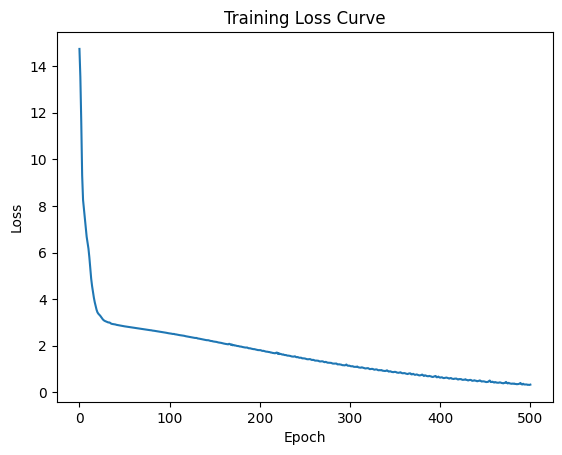

In [6]:
import matplotlib.pyplot as plt

plt.plot(range(len(model.loss_vals)), model.loss_vals)
plt.title("Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# Inference on train data

In [7]:
result = model.generate(X_train, start_token=0, max_len=seq_len)

print(result[:5])
print(y_train[:5])

[[ 0 20 13  3 10  1]
 [ 0 13 19 13 13  2]
 [ 0 10 19 10  1 20]
 [ 0 20  4 13  4 12]
 [ 0 13  4 13  1 14]]
[[20 13  3 10  1]
 [13 19 13 13  2]
 [10 19 10  1 20]
 [20  4  4 13 12]
 [13  4 13  1 14]]


# Inference on test data

In [8]:
X_test = np.array([[2, 4, 6, 8, 10],
                   [15, 12, 9, 6, 3]])

y_test = np.array([[10, 8, 6, 4, 2],
                   [3, 6, 9, 12, 15]])

result = model.generate(X_test, start_token=0, max_len=seq_len)

print(result[:5])
print(y_test[:5])

[[ 0 10  6  8 20  2]
 [ 0  6  3 12 17 15]]
[[10  8  6  4  2]
 [ 3  6  9 12 15]]
